In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [29]:
df = pd.read_csv("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 2/customer_behavior_data.csv")   # <-- update path
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


# STEP 1: Data Cleaning & Preparation

In [30]:
df.isnull().sum()

df['Date'] = pd.to_datetime(df['Date'])
df.info()

df.duplicated().sum()
df = df.drop_duplicates()

# derived columns
df['Calculated_Total'] = df['Unit_Price'] * df['Quantity'] - df['Discount_Amount']
df['Difference'] = df['Total_Amount'] - df['Calculated_Total']

# Encode Categorical Variables (for later use)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1, 'Other': 2})
df['Is_Returning_Customer'] = df['Is_Returning_Customer'].astype(int)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  17049 non-null  object        
 1   Customer_ID               17049 non-null  object        
 2   Date                      17049 non-null  datetime64[ns]
 3   Age                       17049 non-null  int64         
 4   Gender                    17049 non-null  object        
 5   City                      17049 non-null  object        
 6   Product_Category          17049 non-null  object        
 7   Unit_Price                17049 non-null  float64       
 8   Quantity                  17049 non-null  int64         
 9   Discount_Amount           17049 non-null  float64       
 10  Total_Amount              17049 non-null  float64       
 11  Payment_Method            17049 non-null  object        
 12  Device_Type       

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Calculated_Total,Difference
0,ORD_000001-1,CUST_00001,2023-05-29,40,0,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,1,13,4,29.18,0.000000e+00
1,ORD_000001-2,CUST_00001,2023-10-12,40,0,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,1,6,2,506.35,5.684342e-14
2,ORD_000001-3,CUST_00001,2023-12-05,40,0,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,1,9,4,1664.10,0.000000e+00
3,ORD_000002-1,CUST_00002,2023-05-11,33,0,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,1,4,4,275.45,0.000000e+00
4,ORD_000002-2,CUST_00002,2023-06-16,33,0,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,1,6,4,534.45,0.000000e+00


# STEP 2: Feature Engineering

In [31]:
df['Date'] = pd.to_datetime(df['Date'])

reference_date = df['Date'].max() + pd.Timedelta(days=1)

def mode_func(x):
    return x.mode()[0] if not x.mode().empty else np.nan

customer_df = df.groupby('Customer_ID').agg({
    'Total_Amount': ['sum', 'mean'],
    'Quantity': 'sum',
    'Order_ID': 'nunique',
    'Date': lambda x: (reference_date - x.max()).days,
    'Session_Duration_Minutes': 'mean',
    'Pages_Viewed': 'mean',
    'Device_Type': mode_func,
    'Is_Returning_Customer': 'mean',
    'Customer_Rating': 'mean',
    'Delivery_Time_Days': 'mean',
    'Age': 'first',
    'Gender': mode_func,
    'City': mode_func
})

customer_df.columns = [
    'Total_Spend', 'Avg_Order_Value', 'Total_Quantity', 'Number_of_Orders',
    'Recency', 'Avg_Session_Duration', 'Avg_Pages_Viewed', 'Preferred_Device',
    'Returning_Rate', 'Avg_Customer_Rating', 'Avg_Delivery_Time',
    'Age', 'Gender', 'City'
]

customer_df = customer_df.reset_index()

customer_df['Purchase_Frequency'] = (
    customer_df['Number_of_Orders'] /
    (df['Date'].max() - df['Date'].min()).days
)

print(customer_df.head())
print(customer_df.shape)

  Customer_ID  Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  \
0  CUST_00001      2199.63       733.210000               7                 3   
1  CUST_00002       809.90       404.950000               8                 2   
2  CUST_00003      3030.81      1515.405000               7                 2   
3  CUST_00004       383.22       383.220000               5                 1   
4  CUST_00005      2422.73       807.576667               8                 3   

   Recency  Avg_Session_Duration  Avg_Pages_Viewed Preferred_Device  \
0      112             14.333333          9.000000           Mobile   
1      284             15.000000         10.000000          Desktop   
2       83             10.500000          8.500000          Desktop   
3       42             16.000000         15.000000          Desktop   
4      279             12.666667          9.333333           Mobile   

   Returning_Rate  Avg_Customer_Rating  Avg_Delivery_Time  Age  Gender  \
0        1.0

# STEP 3: Feature Selection

C:\Users\Admin\AppData\Local\Temp\ipykernel_19308\389593561.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  selected_df[col].fillna(selected_df[col].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19308\389593561.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

  Customer_ID  Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  \
0  CUST_00001      2199.63       733.210000               7                 3   
1  CUST_00002       809.90       404.950000               8                 2   
2  CUST_00003      3030.81      1515.405000               7                 2   
3  CUST_00004       383.22       383.220000               5                 1   
4  CUST_00005      2422.73       807.576667               8                 3   

   Recency  Avg_Session_Duration  Avg_Pages_Viewed  Returning_Rate  \
0      112             14.333333          9.000000        1.000000   
1      284             15.000000         10.000000        1.000000   
2       83             10.500000          8.500000        0.500000   
3       42             16.000000         15.000000        0.000000   
4      279             12.666667          9.333333        0.666667   

   Avg_Customer_Rating  Avg_Delivery_Time  Age  Purchase_Frequency  \
0             3.333333

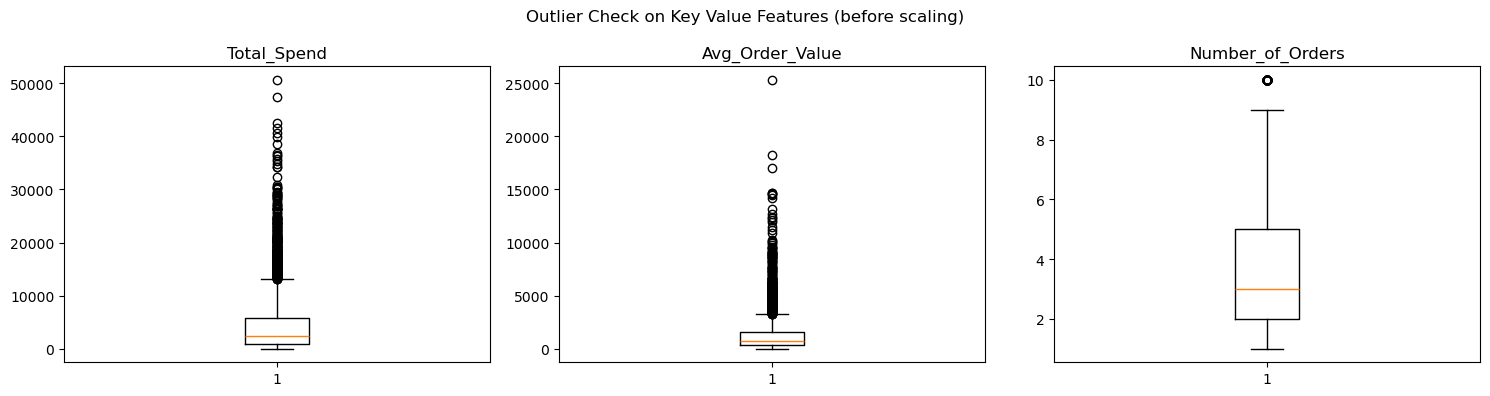

Capping 50 outlier rows in Total_Spend at 99th percentile (24654.41)
Capping 50 outlier rows in Avg_Order_Value at 99th percentile (7672.46)


In [32]:
features_df = customer_df.copy()

numeric_features = [
    'Total_Spend', 'Avg_Order_Value', 'Total_Quantity', 'Number_of_Orders',
    'Recency', 'Avg_Session_Duration', 'Avg_Pages_Viewed', 'Returning_Rate',
    'Avg_Customer_Rating', 'Avg_Delivery_Time', 'Age', 'Purchase_Frequency'
]

# Kept separately for PROFILING ONLY — not fed into the clustering distance
# calculation in Step 4 (Fix #3 & #4: avoids mixing scaled numeric data with
# one-hot City/Device/Gender dummies in the same Euclidean space).
categorical_features = ['Preferred_Device', 'Gender', 'City']

selected_df = features_df[['Customer_ID'] + numeric_features + categorical_features].copy()

# Handle missing values
for col in numeric_features:
    selected_df[col].fillna(selected_df[col].median(), inplace=True)

for col in categorical_features:
    selected_df[col].fillna(selected_df[col].mode()[0], inplace=True)

print(selected_df.head())

# --- Outlier check before scaling (Fix #2) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Total_Spend', 'Avg_Order_Value', 'Number_of_Orders']):
    ax.boxplot(selected_df[col])
    ax.set_title(col)
plt.suptitle("Outlier Check on Key Value Features (before scaling)")
plt.tight_layout()
plt.show()

# Cap extreme outliers at the 99th percentile so a few whales don't drag
# KMeans centroids around (since KMeans is distance-based and outlier-sensitive)
for col in ['Total_Spend', 'Avg_Order_Value']:
    cap = selected_df[col].quantile(0.99)
    n_capped = (selected_df[col] > cap).sum()
    print(f"Capping {n_capped} outlier rows in {col} at 99th percentile ({cap:.2f})")
    selected_df[col] = np.where(selected_df[col] > cap, cap, selected_df[col])

# STEP 4: Apply Clustering Algorithm

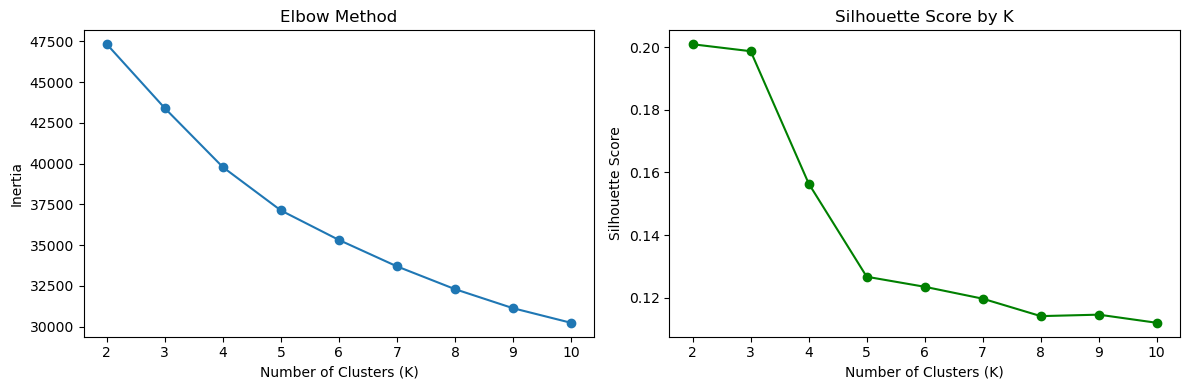

Silhouette scores by K: {2: np.float64(0.201), 3: np.float64(0.199), 4: np.float64(0.156), 5: np.float64(0.127), 6: np.float64(0.123), 7: np.float64(0.12), 8: np.float64(0.114), 9: np.float64(0.115), 10: np.float64(0.112)}
Best K by silhouette score: 2
Final model: K=2, Silhouette Score = 0.201
  Customer_ID  Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  \
0  CUST_00001      2199.63       733.210000               7                 3   
1  CUST_00002       809.90       404.950000               8                 2   
2  CUST_00003      3030.81      1515.405000               7                 2   
3  CUST_00004       383.22       383.220000               5                 1   
4  CUST_00005      2422.73       807.576667               8                 3   

   Recency  Avg_Session_Duration  Avg_Pages_Viewed  Returning_Rate  \
0      112             14.333333          9.000000        1.000000   
1      284             15.000000         10.000000        1.000000   
2      

In [48]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(selected_df[numeric_features])
 
# --- Find optimal K: Elbow Method + Silhouette Score (Fix #1) ---
inertia = []
silhouette_scores = []
K_range = range(2, 11)
 
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(scaled_data)
    inertia.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels_temp))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertia, marker='o')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
 
axes[1].plot(list(K_range), silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
plt.tight_layout()
plt.show()
 
print("Silhouette scores by K:", dict(zip(K_range, np.round(silhouette_scores, 3))))
 
best_k_by_silhouette = list(K_range)[int(np.argmax(silhouette_scores))]
print(f"Best K by silhouette score: {best_k_by_silhouette}")
 
# Decision: use K=2. The data does not show strong natural separation beyond
# two groups -- customer behavior here is largely a continuous spend spectrum
# rather than distinct sub-populations. Rather than forcing extra clusters
# and inventing persona names that don't clearly hold up, we keep the
# simplest, most defensible split and name clusters directly from their
# characteristics (High Value vs Low Value) below.
k = 2
 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)
 
# Quantitative validation of the final model (Fix #5)
final_silhouette = silhouette_score(scaled_data, clusters)
print(f"Final model: K={k}, Silhouette Score = {final_silhouette:.3f}")
 
selected_df['Cluster'] = clusters
 
print(selected_df.head())
print(selected_df['Cluster'].value_counts())

# STEP 5: Analyze Clusters

In [49]:
cluster_summary = selected_df.groupby('Cluster')[numeric_features].mean()
 
device_summary = selected_df.groupby('Cluster')['Preferred_Device'].agg(lambda x: x.mode()[0])
gender_summary = selected_df.groupby('Cluster')['Gender'].agg(lambda x: x.mode()[0])
city_summary = selected_df.groupby('Cluster')['City'].agg(lambda x: x.mode()[0])
 
cluster_size = selected_df['Cluster'].value_counts().sort_index()
cluster_percent = (cluster_size / len(selected_df)) * 100
 
cluster_profile = cluster_summary.copy()
cluster_profile['Most_Common_Device'] = device_summary
cluster_profile['Most_Common_Gender'] = gender_summary
cluster_profile['Most_Common_City'] = city_summary
cluster_profile['Cluster_Size'] = cluster_size
cluster_profile['Cluster_%'] = cluster_percent
 
print("\nFinal Cluster Profile:")
print(cluster_profile)


Final Cluster Profile:
         Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  \
Cluster                                                                   
0        2333.112910      1060.750961        6.689548          2.287288   
1        9036.130596      1648.462775       18.945205          6.131507   

            Recency  Avg_Session_Duration  Avg_Pages_Viewed  Returning_Rate  \
Cluster                                                                       
0        152.548870             14.571455          8.971860        0.776544   
1         60.656849             14.507462          9.040134        0.935974   

         Avg_Customer_Rating  Avg_Delivery_Time        Age  \
Cluster                                                      
0                   3.909317           6.531756  35.201130   
1                   3.884509           6.493219  34.623973   

         Purchase_Frequency Most_Common_Device  Most_Common_Gender  \
Cluster                                

# STEP 6: Name Clusters Directly from Their Characteristics + Recommended Actions 

In [50]:
# With K=2, we don't need an invented persona-assignment function with
# arbitrary thresholds. We name each cluster directly based on which one
# has the higher mean Total_Spend -- this is the cluster's defining
# characteristic, straight from cluster_summary, not a guessed label.
cluster_value_rank = cluster_summary['Total_Spend'].sort_values(ascending=False)
high_value_cluster = cluster_value_rank.index[0]
low_value_cluster = cluster_value_rank.index[1]
 
cluster_to_label = {
    high_value_cluster: "High Value Customers",
    low_value_cluster: "Low Value Customers"
}
 
persona_df = cluster_summary.copy()
persona_df['Persona'] = persona_df.index.map(cluster_to_label)
 
# Map persona -> recommended business action
PERSONA_ACTIONS = {
    "High Value Customers": "Higher spend, more orders, and/or more recent activity. "
                             "Prioritize retention: loyalty rewards, early access to new "
                             "products, and personalized offers to protect this segment's LTV.",
    "Low Value Customers": "Lower spend and/or fewer orders. Focus on activation: "
                            "first-purchase incentives, value bundles, free shipping "
                            "thresholds, and win-back campaigns for the most inactive customers "
                            "within this group."
}
persona_df['Recommended_Action'] = persona_df['Persona'].map(PERSONA_ACTIONS)
 
persona_map = persona_df['Persona'].to_dict()
selected_df['Persona'] = selected_df['Cluster'].map(persona_map)
 
print("\nCluster -> Persona mapping (based on mean Total_Spend):")
print(cluster_value_rank)
print("\nPersona Summary with Recommended Actions:")
print(persona_df[['Persona', 'Recommended_Action']])
 
selected_df.head()


Cluster -> Persona mapping (based on mean Total_Spend):
Cluster
1    9036.130596
0    2333.112910
Name: Total_Spend, dtype: float64

Persona Summary with Recommended Actions:
                      Persona  \
Cluster                         
0         Low Value Customers   
1        High Value Customers   

                                        Recommended_Action  
Cluster                                                     
0        Lower spend and/or fewer orders. Focus on acti...  
1        Higher spend, more orders, and/or more recent ...  


,Customer_ID,Total_Spend,Avg_Order_Value,Total_Quantity,Number_of_Orders,Recency,Avg_Session_Duration,Avg_Pages_Viewed,Returning_Rate,Avg_Customer_Rating,Avg_Delivery_Time,Age,Purchase_Frequency,Preferred_Device,Gender,City,Cluster,Persona
0,CUST_00001,2199.63,733.210000,7,3,112,14.333333,9.000000,1.000000,3.333333,9.333333,40,0.006682,Mobile,0,Ankara,0,Low Value Customers
1,CUST_00002,809.90,404.950000,8,2,284,15.000000,10.000000,1.000000,4.000000,5.000000,33,0.004454,Desktop,0,Istanbul,0,Low Value Customers
2,CUST_00003,3030.81,1515.405000,7,2,83,10.500000,8.500000,0.500000,3.500000,6.000000,42,0.004454,Desktop,0,Konya,0,Low Value Customers
3,CUST_00004,383.22,383.220000,5,1,42,16.000000,15.000000,0.000000,5.000000,4.000000,53,0.002227,Desktop,0,Izmir,0,Low Value Customers
4,CUST_00005,2422.73,807.576667,8,3,279,12.666667,9.333333,0.666667,3.666667,5.666667,32,0.006682,Mobile,0,Ankara,0,Low Value Customers


# Visualization

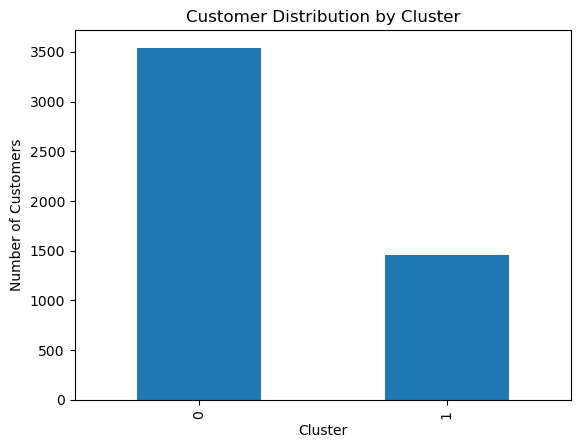

In [51]:
cluster_counts = selected_df['Cluster'].value_counts().sort_index()
cluster_counts.plot(kind='bar')
plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

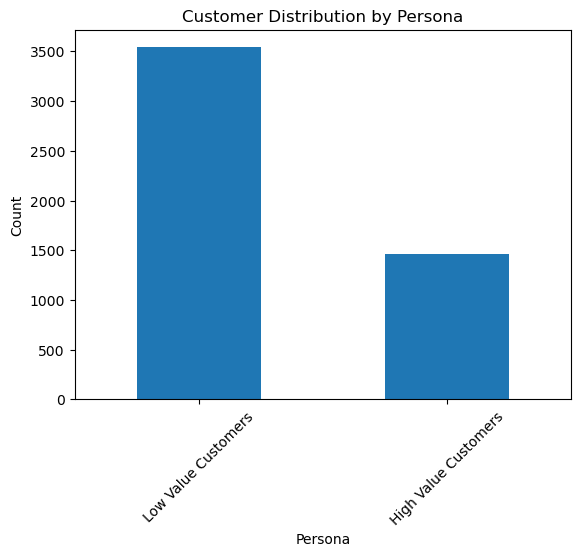

In [52]:
persona_counts = selected_df['Persona'].value_counts()
persona_counts.plot(kind='bar')
plt.title('Customer Distribution by Persona')
plt.xlabel('Persona')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

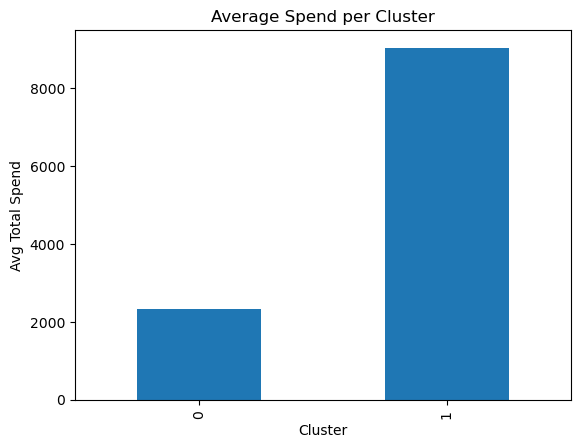

In [53]:
selected_df.groupby('Cluster')['Total_Spend'].mean().plot(kind='bar')
plt.title('Average Spend per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Avg Total Spend')
plt.show()

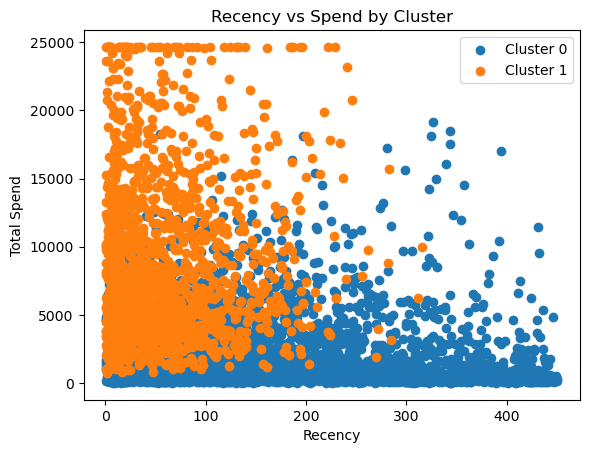

In [54]:
plt.figure()
for cluster in sorted(selected_df['Cluster'].unique()):
    subset = selected_df[selected_df['Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Total_Spend'], label=f'Cluster {cluster}')
plt.xlabel('Recency')
plt.ylabel('Total Spend')
plt.title('Recency vs Spend by Cluster')
plt.legend()
plt.show()

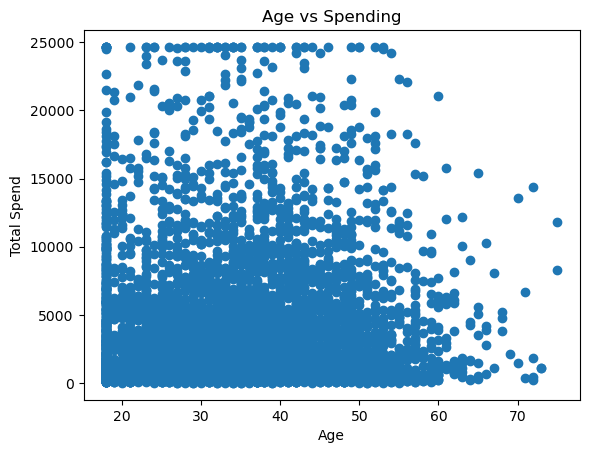

In [55]:
plt.figure()
plt.scatter(selected_df['Age'], selected_df['Total_Spend'])
plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('Age vs Spending')
plt.show()

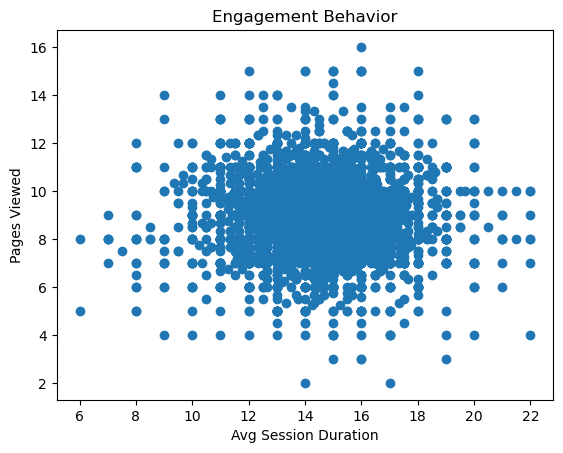

In [56]:
plt.figure()
plt.scatter(selected_df['Avg_Session_Duration'], selected_df['Avg_Pages_Viewed'])
plt.xlabel('Avg Session Duration')
plt.ylabel('Pages Viewed')
plt.title('Engagement Behavior')
plt.show()

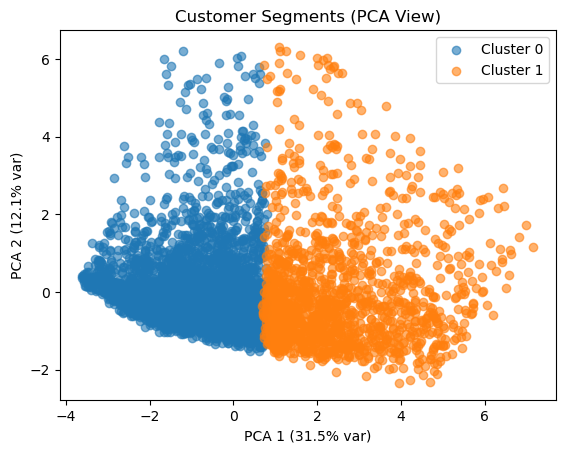


PCA explains 43.6% of total variance in 2 components.
Interpretation: well-separated clusters in this plot indicate the segments are genuinely distinct in behavior space, not just arbitrary groupings caused by noise.


In [57]:
# PCA Visualization — built on the SAME scaled numeric data used for
# clustering (Fix #4 consistency), with variance explained + interpretation (Fix #6)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
explained = pca.explained_variance_ratio_

plt.figure()
for cluster in sorted(selected_df['Cluster'].unique()):
    mask = selected_df['Cluster'] == cluster
    plt.scatter(pca_data[mask, 0], pca_data[mask, 1], label=f'Cluster {cluster}', alpha=0.6)
plt.xlabel(f'PCA 1 ({explained[0]*100:.1f}% var)')
plt.ylabel(f'PCA 2 ({explained[1]*100:.1f}% var)')
plt.title('Customer Segments (PCA View)')
plt.legend()
plt.show()

print(f"\nPCA explains {sum(explained)*100:.1f}% of total variance in 2 components.")
print("Interpretation: well-separated clusters in this plot indicate the segments are "
      "genuinely distinct in behavior space, not just arbitrary groupings caused by noise.")

# Insights

In [59]:
print("\n🔍 Insights:")
for i, row in cluster_profile.iterrows():
    print(f"\nCluster {i}:")
    print(f"- Avg Spend: {row['Total_Spend']:.2f}")
    print(f"- Orders: {row['Number_of_Orders']:.2f}")
    print(f"- Recency: {row['Recency']:.2f}")
    print(f"- Cluster Size: {row['Cluster_Size']} ({row['Cluster_%']:.2f}%)")
 
print(f"\nModel quality: K={k}, Silhouette Score={final_silhouette:.3f}")


🔍 Insights:

Cluster 0:
- Avg Spend: 2333.11
- Orders: 2.29
- Recency: 152.55
- Cluster Size: 3540 (70.80%)

Cluster 1:
- Avg Spend: 9036.13
- Orders: 6.13
- Recency: 60.66
- Cluster Size: 1460 (29.20%)

Model quality: K=2, Silhouette Score=0.201


# Project Summary

In [60]:
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"Customers analyzed: {len(selected_df)}")
print(f"Features used for clustering: {numeric_features}")
print(f"Optimal K selected (by silhouette score): {k}")
print(f"Final Silhouette Score: {final_silhouette:.3f}")
print("\nSegment sizes:")
print(cluster_size.to_string())
print("\nPersonas identified and their recommended actions:")
for cluster_id, row in persona_df.iterrows():
    print(f"  Cluster {cluster_id} -> {row['Persona']}")
    print(f"    Action: {row['Recommended_Action']}")
print("\nNote: clustering is unsupervised, so silhouette score (not accuracy) "
      "was used to validate cluster quality, since there is no ground-truth label.")
print("=" * 60)


PROJECT SUMMARY
Customers analyzed: 5000
Features used for clustering: ['Total_Spend', 'Avg_Order_Value', 'Total_Quantity', 'Number_of_Orders', 'Recency', 'Avg_Session_Duration', 'Avg_Pages_Viewed', 'Returning_Rate', 'Avg_Customer_Rating', 'Avg_Delivery_Time', 'Age', 'Purchase_Frequency']
Optimal K selected (by silhouette score): 2
Final Silhouette Score: 0.201

Segment sizes:
Cluster
0    3540
1    1460

Personas identified and their recommended actions:
  Cluster 0 -> Low Value Customers
    Action: Lower spend and/or fewer orders. Focus on activation: first-purchase incentives, value bundles, free shipping thresholds, and win-back campaigns for the most inactive customers within this group.
  Cluster 1 -> High Value Customers
    Action: Higher spend, more orders, and/or more recent activity. Prioritize retention: loyalty rewards, early access to new products, and personalized offers to protect this segment's LTV.

Note: clustering is unsupervised, so silhouette score (not accuracy